#Image classification + OOP

In [1]:
# Run setup
!pip install -q torch torchvision scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

from utils.download_data import download_mnist, prepare_for_rf, prepare_for_torch
from classifiers.mnist_classifier import MnistClassifier

In [3]:
#Load MNIST dataset
trainset, testset = download_mnist()

100.0%
100.0%
100.0%
100.0%


In [4]:
# For Random Forest (numpy arrays)
X_train_rf, y_train_rf, X_test_rf, y_test_rf = prepare_for_rf(trainset, testset)

# For Neural Networks (tensors)
X_train_torch, y_train_torch, X_test_torch, y_test_torch = prepare_for_torch(trainset, testset)

In [5]:
# Random Forest
rf_model = MnistClassifier(algorithm="rf", n_estimators=100)
rf_model.train(X_train_rf, y_train_rf)
rf_predicts = rf_model.predict(X_test_rf)

rf_acc = accuracy_score(y_test_rf, rf_predicts)
print(f"Random Forest Accuracy: {rf_acc*100:.2f}%")

Random Forest Accuracy: 97.05%


In [6]:
# Feed-Forward Neural Network
nn_model = MnistClassifier(algorithm="nn", epochs=3, batch_size=128)
nn_model.train(X_train_torch, y_train_torch)
nn_predicts = nn_model.predict(X_test_torch)

nn_acc = accuracy_score(y_test_torch, nn_predicts)
print(f"Feed-Forward NN Accuracy: {nn_acc*100:.2f}%")

Feed-Forward NN Accuracy: 95.79%


In [7]:
# Convolutional Neural Network
cnn_model = MnistClassifier(algorithm="cnn", epochs=3, batch_size=128)
cnn_model.train(X_train_torch, y_train_torch)
cnn_predicts = cnn_model.predict(X_test_torch)

cnn_acc = accuracy_score(y_test_torch, cnn_predicts)
print(f"CNN Accuracy: {cnn_acc*100:.2f}%")

CNN Accuracy: 99.02%


In [8]:
# Compare all results
print("\n Compare results:")
print(f"Random Forest   : {rf_acc*100:.2f}%")
print(f"Feed-Forward NN : {nn_acc*100:.2f}%")
print(f"CNN             : {cnn_acc*100:.2f}%")


 Compare results:
Random Forest   : 97.05%
Feed-Forward NN : 95.79%
CNN             : 99.02%


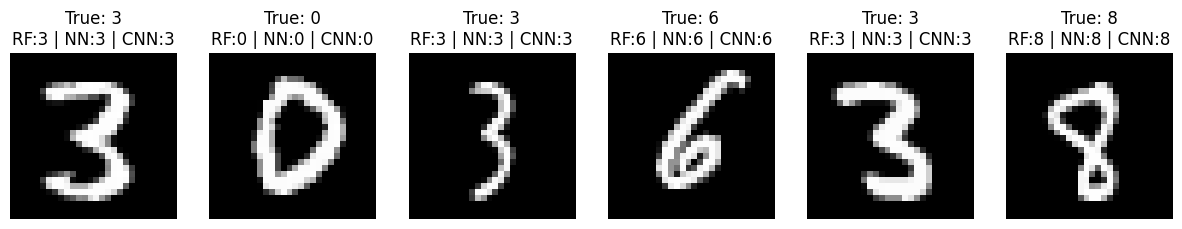

In [9]:
# Visualization of predictions
def show_predictions(images, true_labels, rf_preds, nn_preds, cnn_preds, n=6):
    """
    Display MNIST images with predictions of all three classifiers.
    """
    plt.figure(figsize=(15, 3))
    for item in range(n):
        idx = np.random.randint(0, len(images))
        img = images[idx].squeeze()
        ground_truth = true_labels[idx].item()
        rf_p = rf_preds[idx]
        nn_p = nn_preds[idx].item()
        cnn_p = cnn_preds[idx].item()

        plt.subplot(1, n, item+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"True: {ground_truth}\nRF:{rf_p} | NN:{nn_p} | CNN:{cnn_p}")
        plt.axis("off")
    plt.show()

show_predictions(X_test_torch, y_test_torch, rf_predicts, nn_predicts, cnn_predicts, n=6)

### Example Prediction Insights
- All three models correctly classify the shown test digits.
- There are no misclassifications in this sample, demonstrating that even simple digits are handled accurately.
- Random Forest, Feed-Forward NN, and CNN all produce identical and correct predictions for these cases.
- This illustrates the consistency and reliability of the models on clear, unambiguous digits.


### Summary
- The Random Forest model reached around 97% accuracy, providing a solid benchmark for MNIST classification.
- The Feed-Forward Neural Network obtained approximately 96%, demonstrating effective learning, though slightly behind due to its simpler structure.
- The Convolutional Neural Network achieved near 99% accuracy, confirming that CNNs are highly effective for image recognition tasks.